## Map of sea Ice:



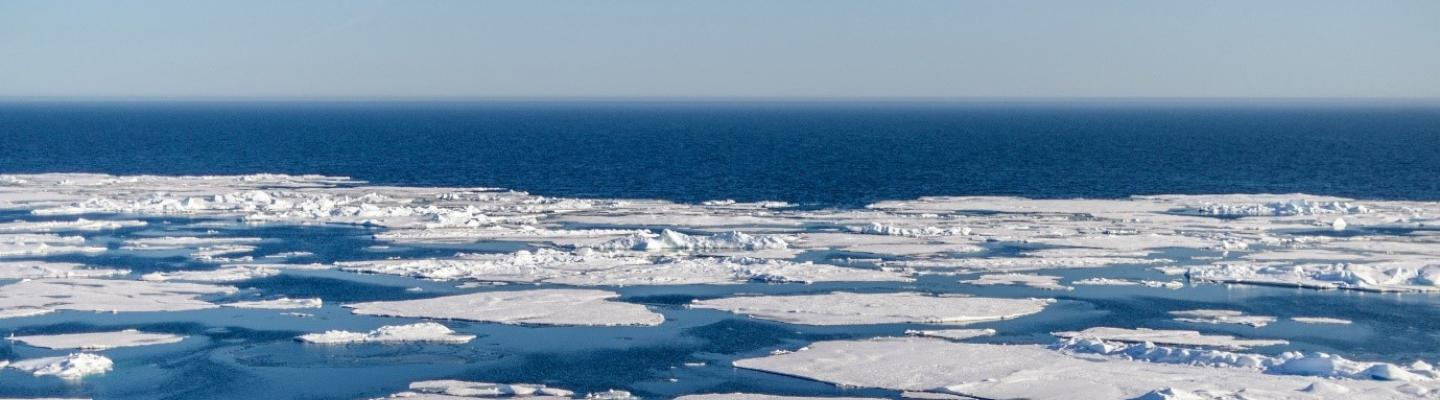

| Topic|Link|
|-|-|
|ESGF|https://aims2.llnl.gov/cart/items|

First, I am adding the EC3 ARChmip Model to my dataset for the ERF and EMIDMS in 2x and control.
Then I'm going through these maps of sea ice!

### Why siconc (Sea Ice Concentration) Is Essential
DMS is emitted from open ocean areas — sea ice inhibits DMS emissions because:

+ Ice-covered regions block sunlight, reducing phytoplankton (DMS producers).

+ Sea ice physically prevents gas exchange between ocean and atmosphere.

Therefore:

+  High siconc → Lower DMS emissions
+  Low siconc (open water) → Higher DMS emissions



**CMIP6 Data Query Parameters**  

| Key            | Value(s)                                  |
|----------------|------------------------------------------|
| `latest`       | `True`                                   |
| `activity_id`  | `AerChemMIP`, `CMIP`                     |
| `source_id`    | `EC-Earth3-AerChem`, `GISS-E2-1-G`,<br>`NorESM2-LM`, `UKESM1-0-LL` |
| `experiment_id`| `piClim-2xDMS`, `piControl`              |
| `frequency`    | `mon`                                    |
| `realm`        | `seaIce`                                 |
| `table_id`     | `SImon`                                  |
| `variable_id`  | `siconc`                                 |

**Tips**:
+ GISS only on the  `H`  model has siconc feature!
+ Only pi control no 2x DMS!

now ineed to average and plot data! or need to mask?!! 

In [1]:
from common_imports import *
model_data = load_all_data()

In [2]:
#print(model_data['UKESM']['control']['siconc'])

In [3]:
# data = model_data['UKESM']['control']['siconc']
# print(data)  # Prints summary (dimensions, coordinates, attributes)
# print("Values (first few):", data.values[:5])  # Access underlying NumPy array
# print("NaN count:", data.isnull().sum().values)  # Count NaN
# print("Zero count:", (data == 0).sum().values)  # Count zeros
# print("Coordinates:", data.coords)  # Check dimensions (time, lat, lon, etc.)
# # Count non-zero, non-NaN values
# count = np.sum((data != 0) & (~np.isnan(data)))
# print("Non-zero, non-NaN count:", count)

In [4]:
#erf_results, erf_data, emidms_results, emidms_data, siconc_results, siconc_data = analyze_erf_emidms_siconc(model_data, time_slice=(None, None))


In [5]:
#print_results(erf_results)

In [6]:
#print(model_data['EC-AEREarth3']['control']['rlut'])

In [7]:
#diagnose_model_inputs(model_data)

In [8]:
#print(diagnose_model_inputs)

In [9]:
#print(siconc_data)

In [10]:
#print(model_data['UKESM']['control']['siconc'].type)

In [11]:
# results = analyze_erf_emidms_siconc(model_data, time_slice=(None, None))
# erf_results, erf_data, emidms_results, emidms_data, siconc_results, siconc_data = results

# # Create a list of variable configurations
# variables_to_plot = [
#     {"data": erf_data, "name": "Effective Radiative Forcing", "save_dir": "plots_erf", "unit": "W/m²", "cmap": "RdBu_r"},
#     {"data": emidms_data, "name": "DMS Emissions", "save_dir": "plots_emidms", "unit": "kg m⁻² s⁻¹", "cmap": "viridis"}
#     ]

# # Loop through and plot
# for var in variables_to_plot:
#     print(f"\n🔷 Plotting {var['name']}...")
#     plot_all_data_maps(
#         data_dict=var["data"],
#         variable_name=var["name"],
#         save_dir=var["save_dir"],
#         cmap=var["cmap"],
#         unit=var["unit"]
#     )

In [12]:
# plot_siconc_maps(
#         siconc_dict=siconc_data,
#         save_dir="plots_siconc",
#         dpi=400,          # crisper PNG without huge memory
#         smooth=True       # bilinear shading but no re-gridding
# )

In [13]:
import xarray as xr
from plot_siconc import plot_siconc_maps

# Load SICONC files (monthly SImon), take a climatology if you want
ec = xr.open_dataset("siconc_SImon_EC-Earth3-AerChem_piControl_r1i1p4f1_gn_185001-185012.nc")["siconc"]
gi = xr.open_dataset("siconc_SImon_GISS-E2-1-H_piControl_r1i1p3f1_gr_200001-201912.nc")["siconc"]
no = xr.open_dataset("siconc_SImon_NorESM2-LM_piControl_r1i1p1f1_gn_160001-160912.nc")["siconc"]

# Build your dict (example: Arctic + Global)
siconc_dict = {
    "EC-Earth3-AerChem": {"piControl": {"Arctic": ec, "Global": ec}},
    "GISS-E2-1-H":       {"piControl": {"Arctic": gi}},
    "NorESM2-LM":        {"piControl": {"Arctic": no}},
}

# Optional: provide emidms and erf on roughly the same domain/time (or they’ll be interpolated)
# emidms = xr.open_dataset("path_to_emidms.nc")["emidms"]
# erf    = xr.open_dataset("path_to_erf.nc")["erf"]

# plot_siconc_maps(
#     siconc_dict,
#     save_dir="plots_siconc",
#     cmap="Blues",
#     vmin=0.0, vmax=100.0,          # fixed scale for comparability
#     add_ice_edge=True,
#     step1_inputs=None,             # or {"emidms": emidms, "region": "Arctic"}
#     step2_inputs=None,             # or {"erf": erf, "region": "Arctic"}
# )

In [14]:
#from siconcsidebyside import plot_siconc_panel_side_by_side
# plot_siconc_panel_side_by_side(
#     siconc_dict,
#     region="Arctic",
#     exp="piControl",
#     models=["EC-Earth3-AerChem", "GISS-E2-1-H", "NorESM2-LM"],  # or leave None to auto-pick
#     save_dir="plots_siconc", view_lat_min=50, mask_land=True)     # show 50°N–90°N (make 55/60 for tighter view)

In [15]:
from load_data import load_all_data
from run_steps_from_analyzer import run_steps_with_analyzer
import importlib, run_steps_from_analyzer as rsa
importlib.reload(rsa)


# model_data = load_all_data()  # your loader
# res = run_steps_with_analyzer(
#     model_data,
#     time_slice=(None, None),      # or (0, 120) etc. if you want to subselect in analyzer
#     region="Arctic",
#     preferred_em_exp="control",
#     save_dir="plots_steps"
# )
# print(res)

<module 'run_steps_from_analyzer' from '/mnt/data-summer-user/shahab-lab/run_steps_from_analyzer.py'>

In [ ]:
from analyze_erf_emidms_siconc import analyze_erf_emidms_siconc
from linkage_sulfate_graphs import plot_sulfate_linkage_model


# 1) run your analyzer (once)
(erf_results, erf_data,
 emidms_results, emidms_data,
 siconc_results, siconc_data,
 mmrso4_results, mmrso4_data) = analyze_erf_emidms_siconc(model_data)

# 2) make the linkage summary figure for each model you care about
plot_sulfate_linkage_model(
    mmrso4_data=mmrso4_data,
    siconc_data=siconc_data,
    emidms_data=emidms_data,
    erf_data=erf_data,            # you can pass None to skip ERF panel
    model="GISS",
    region="Arctic",
    save_dir="images"
)

plot_sulfate_linkage_model(
    mmrso4_data=mmrso4_data,
    siconc_data=siconc_data,
    emidms_data=emidms_data,
    erf_data=erf_data,
    model="NorESM",
    region="Arctic",
    save_dir="images"
)


🔷 UKESM – control – Global
🔷 UKESM – control – Arctic
🔷 UKESM – control – Antarctic
